# Books Web Scraping and Data Analysis

## 1. Import Libraries
This section imports the required Python libraries for web scraping, data analysis, and visualization.

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

## 2. Web Scraping
This section collects book information such as title, price, rating, and availability from the website.

In [4]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [5]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [6]:
books = soup.find_all("article", class_="product_pod")

print("Number of products:", len(books))


Number of products: 20


In [7]:
book = books[0]

print(book)


<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [8]:
title = book.h3.a["title"]

print(title)

A Light in the Attic


In [9]:
price = book.find("p", class_="price_color").text.strip()

print(price)

Â£51.77


In [10]:
rating = book.find("p", class_="star-rating")["class"][1]

print(rating)

Three


In [11]:
availability = book.find("p", class_="availability").text.strip()

print(availability)

In stock


## 3. Creating DataFrame
This section converts the scraped book data into a structured Pandas DataFrame.

In [12]:
data = []

for book in books:
    title = book.h3.a["title"]
    
    price = book.find("p", class_="price_color").text.strip()
    
    rating = book.find("p", class_="star-rating")["class"][1]
    
    availability = book.find("p", class_="availability").text.strip()
    
    data.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability
    })

df = pd.DataFrame(data)

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [13]:
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

all_data = []

for page in range(1, 51):
    url = base_url.format(page)
    
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.find_all("article", class_="product_pod")
    
    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text.strip()
        rating = book.find("p", class_="star-rating")["class"][1]
        availability = book.find("p", class_="availability").text.strip()
        
        all_data.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability
        })

df = pd.DataFrame(all_data)

print("Total books:", len(df))

Total books: 1000


## 4. Data Cleaning
This section cleans and transforms the data for analysis, including converting price and rating values into numeric format.


In [14]:
df["Price"] = df["Price"].str.replace("Â£", "", regex=False).astype(float)

In [15]:
print(df["Price"].head())
print(df["Price"].dtype)


0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64
float64


In [16]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [17]:
print(df["Rating"].head())
print(df["Rating"].dtype)

0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64
int64


In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 31.4 KB
None


## 5. Exploratory Data Analysis
This section explores the dataset structure, summary statistics, missing values, and general patterns.

In [19]:
print(df.head())
print(df.info())
print(df.shape)
print(df.isnull().sum())


                                   Title  Price  Rating Availability
0                   A Light in the Attic  51.77       3     In stock
1                     Tipping the Velvet  53.74       1     In stock
2                             Soumission  50.10       1     In stock
3                          Sharp Objects  47.82       4     In stock
4  Sapiens: A Brief History of Humankind  54.23       5     In stock
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 31.4 KB
None
(1000, 4)
Title           0
Price           0
Rating          0
Availability    0
dtype: int64


In [20]:
print("Average price:", df["Price"].mean())

Average price: 35.07035


In [21]:
print("Minimum price:", df["Price"].min())
print("Maximum price:", df["Price"].max())

Minimum price: 10.0
Maximum price: 59.99


In [22]:
print(df["Price"].describe())

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: Price, dtype: float64


In [ ]:
print(df["Rating"].value_counts().sort_index())

Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [23]:
print("Average price:", df["Price"].mean())

print("Minimum price:", df["Price"].min())

print("Maximum price:", df["Price"].max())

print(df["Rating"].value_counts().sort_index())

Average price: 35.07035
Minimum price: 10.0
Maximum price: 59.99
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [24]:
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)
print("Most common rating:", rating_counts.idxmax())
print("Number of books:", rating_counts.max())

Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64
Most common rating: 1
Number of books: 226


In [25]:
average_price_by_rating = df.groupby("Rating")["Price"].mean()

print(average_price_by_rating)

Rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: Price, dtype: float64


In [26]:
cheapest_books = df.sort_values("Price").head(10)

print(cheapest_books[["Title", "Price", "Rating"]])

                                                 Title  Price  Rating
638                         An Abundance of Katherines  10.00       5
501                              The Origin of Species  10.01       4
716  The Tipping Point: How Little Things Can Make ...  10.02       2
84                                            Patience  10.16       3
302                               Greek Mythic History  10.23       5
558  The Fellowship of the Ring (The Lord of the Ri...  10.27       2
479                                  History of Beauty  10.29       4
242  The Lucifer Effect: Understanding How Good Peo...  10.40       1
434  NaNo What Now? Finding your editing process, r...  10.41       4
274                                       Pet Sematary  10.56       3


In [28]:
most_expensive_books = df.sort_values("Price", ascending=False).head(10)

print(most_expensive_books[["Title", "Price", "Rating"]])

                                                 Title  Price  Rating
648                 The Perfect Play (Play by Play #1)  59.99       3
617                  Last One Home (New Beginnings #1)  59.98       3
860                   Civilization and Its Discontents  59.95       2
560                     The Barefoot Contessa Cookbook  59.92       5
366                          The Diary of a Young Girl  59.90       3
657  The Bone Hunters (Lexy Vaughan & Steven Macaul...  59.71       3
133  Thomas Jefferson and the Tripoli Pirates: The ...  59.64       1
387                      Boar Island (Anna Pigeon #19)  59.48       3
549  The Man Who Mistook His Wife for a Hat and Oth...  59.45       4
393                          The Improbability of Love  59.45       1


In [29]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 22.1075
Q3: 47.457499999999996
IQR: 25.349999999999994
Lower bound: -15.91749999999999
Upper bound: 85.48249999999999


In [30]:
outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


## 6. Data Visualization
This section creates visualizations to better understand price distribution, rating counts, and relationships between variables.

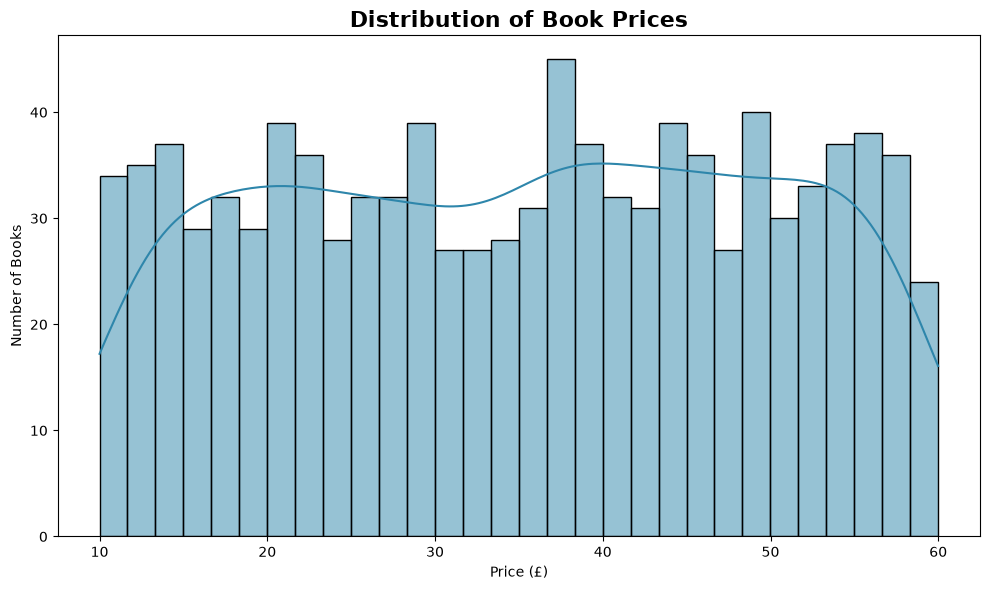

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Price"], bins=30, kde=True, color="#2E86AB")

plt.title("Distribution of Book Prices", fontsize=16, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

The prices are spread fairly evenly between around £10 and £60. There is no strong concentration in one specific price range, which suggests that the scraped books cover a broad range of price points.

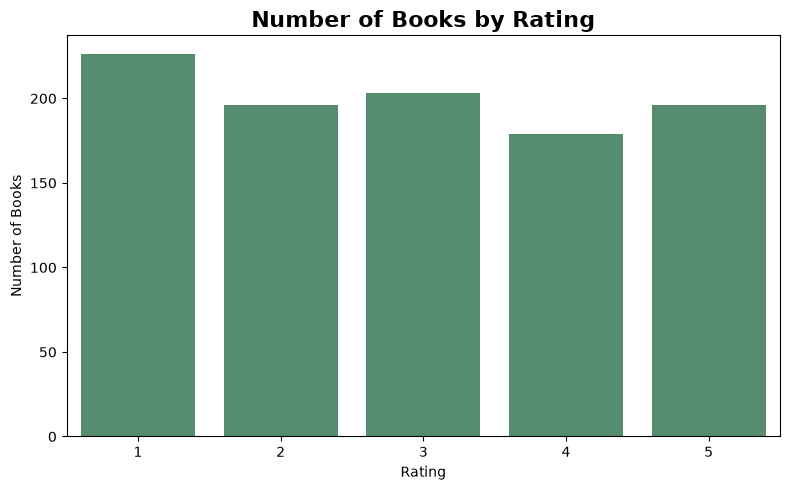

In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Rating", color="#4C956C")

plt.title("Number of Books by Rating", fontsize=16, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

The dataset contains books across all rating levels. Rating 1 has the highest number of books, while Rating 4 has the lowest count. Overall, the rating distribution is relatively balanced.

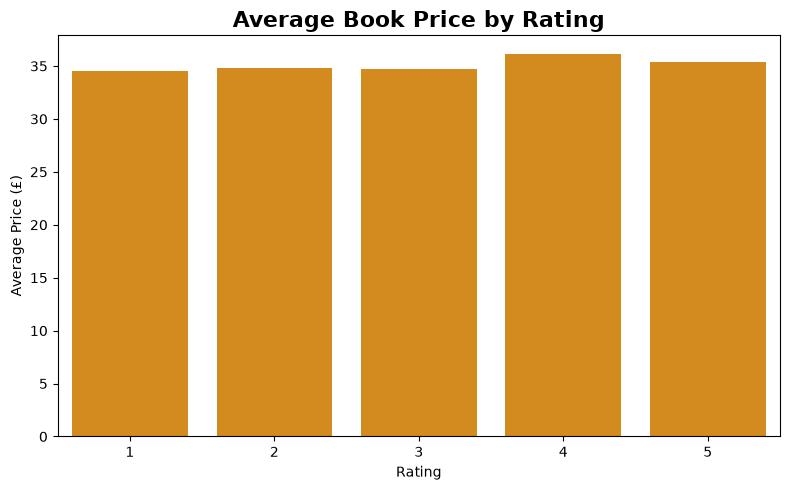

In [33]:
avg_price = df.groupby("Rating")["Price"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_price, x="Rating", y="Price", color="#F18F01")

plt.title("Average Book Price by Rating", fontsize=16, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.tight_layout()
plt.show()

The average prices are very similar across all rating levels. Rating 4 has the highest average price, but the difference is small. This suggests that book rating is not strongly related to price in this dataset.

## 7. Relationship Analysis
This section analyzes the relationship between book rating and price.

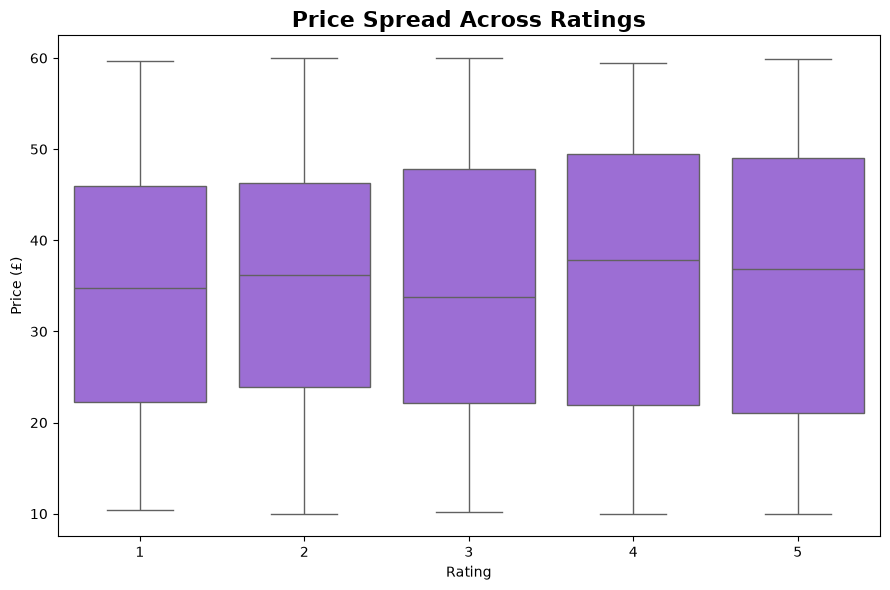

In [34]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Rating", y="Price", color="#9B5DE5")

plt.title("Price Spread Across Ratings", fontsize=16, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

The boxplot shows that each rating group has a wide price range, from low-priced books to high-priced books. The median prices are also close to each other, supporting the idea that rating does not strongly determine book price.

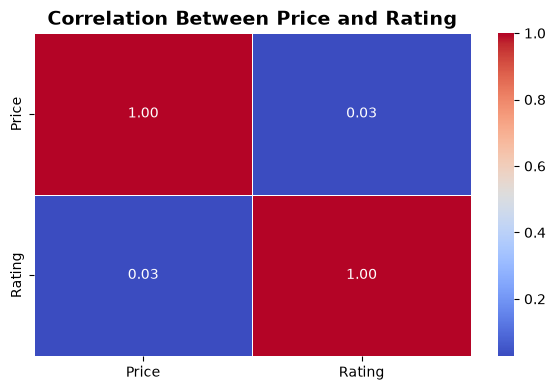

In [35]:
plt.figure(figsize=(6, 4))

corr = df[["Price", "Rating"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Price and Rating", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The correlation value between Price and Rating is 0.03, which shows a very weak positive relationship. This means that book price does not strongly depend on rating. In this dataset, higher-rated books are not necessarily more expensive.

In [36]:
df[["Price", "Rating"]].corr()

,Price,Rating
Price,1.000000,0.028166
Rating,0.028166,1.000000


The correlation between Price and Rating is 0.028, which is very close to 0. This indicates that there is almost no linear relationship between book price and rating. In this dataset, higher-rated books are not necessarily more expensive.

## Conclusion

This project analyzed 1000 books scraped from the Books to Scrape website. After cleaning the price and rating columns, exploratory data analysis was performed using different visualizations.

The analysis showed that book prices are distributed across a wide range, from around £10 to £60. Books are available across all rating levels, and the rating distribution is relatively balanced. The average price across rating groups is very similar, and the correlation between price and rating is only 0.028.

Overall, the results suggest that book rating does not have a strong relationship with book price in this dataset. Higher-rated books are not necessarily more expensive.